In [24]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

In [16]:
prices         = pd.read_parquet('../data/monthly-etf-prices.parquet')
returns        = prices.pct_change().dropna(how='all')

excess_returns = returns - returns['BIL'].values.reshape(-1,1) # use BIL as risk free rate
excess_returns = excess_returns.drop(columns=['BIL'])

### Look at SPY Alone

[]

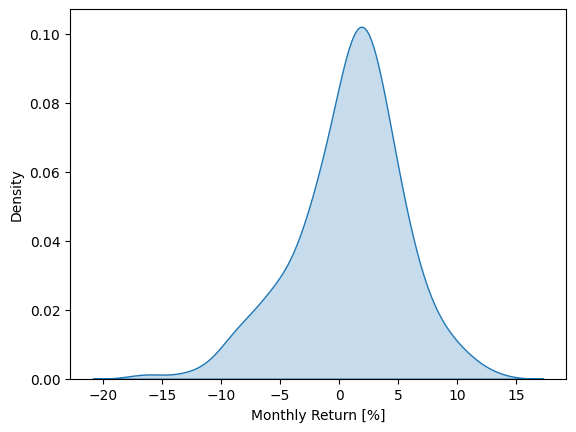

In [64]:
# sns.histplot(excess_returns['SPY'] * 100., fill=True, bins=np.arange(-20,21,1), alpha=0.6, edgecolor='w')
fig, ax = plt.subplots()
sns.kdeplot(excess_returns['SPY'] * 100, fill=True)
ax.set_xlabel('Monthly Return [%]')
plt.plot()

In [ ]:
def get_annualized_sharpe(excess_returns_series, vals_per_year=12):
    '''
    Returns the annualized sharpe ratio
    for the given series of excess returns
    '''
    mean_return = np.mean(excess_returns_series)
    stdv_return = np.std(excess_returns_series)

    return np.sqrt(vals_per_year) * mean_return / stdv_return


def get_drawdown(returns_series):
    '''
    Returns the max drawdown for the given
    returns series
    '''
    running_value = (returns_series + 1).cumprod()
    running_max   = running_value.cummax()

    drawdown_pct  = ((running_value / running_max) - 1) * 100.
    max_drawdown  = drawdown_pct.min()

    return drawdown_pct, max_drawdown